In [1]:
import sisl
import numpy as np
import matplotlib.pyplot as plt
from mytools.scaling import map_index
from mytools.plots import thesis_fig
from mytools.construct import all_armchair

# Global params

In [34]:
BOND = 1.42 # bondlength of graphene

N1 = 5 # tiling of smaller geom
N2 = 11 # tiling of larger geom

# TB params for constructor
R = (0.1, BOND+1e-2)
T = (0., -2.7)

# self energy parameters
ETA = 1e-4 # complex energy permutation
NUM_K = 400 # k-sampling in transverse direction

# Create (armchair) graphene unitcell and TB hamiltonian

In [35]:
graphene6 = all_armchair(BOND)
Ham0 = sisl.Hamiltonian(graphene6)
Ham0.construct([R, T])

# Make real space self energy object for the different geometries

In [36]:
RSSE1 = sisl.RealSpaceSE(Ham0, 0, 1, [N1, N1, 1])
RSSE1.setup(eta=ETA,
            bz=sisl.MonkhorstPack(Ham0, [1, NUM_K, 1]))
RSSE2 = sisl.RealSpaceSE(Ham0, 0, 1, [N2, N2, 1])
RSSE2.setup(eta=ETA,
            bz=sisl.MonkhorstPack(Ham0, [1, NUM_K, 1]))

ElecHam1 = RSSE1.real_space_coupling()
ElecHam2 = RSSE2.real_space_coupling()

# Show the index extrapolating

86
[ 0  1  2  3  4  5  4  5  4  5  4  5  6  7  6  7  8  9  8  9  8  9 10 11
 12 13 14 15 16 13 14 15 16 13 14 15 16 13 14 19 20 17 18 19 20 17 18 23
 24 21 22 23 24 21 22 23 24 21 22 23 24 25 26 27 28 29 28 29 28 29 30 31
 30 31 32 33 32 33 32 33 32 33 34 35 36 37] (86,)


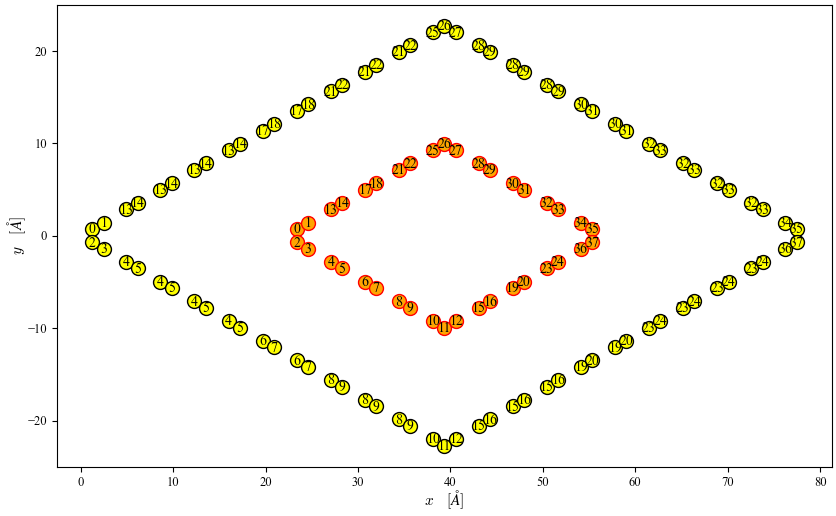

In [ ]:
print(ElecHam2.na)
g1_to_g2_index = map_index(ElecHam1, ElecHam2)
print(g1_to_g2_index, g1_to_g2_index.shape)

xy1 = ElecHam1.xyz[:, :2]
xy2 = ElecHam2.xyz[:, :2]
xy1_shifted = xy1 + xy2.mean(axis=0, keepdims=True) - xy1.mean(axis=0, keepdims=True)

fig, axes = thesis_fig(figsize=(10, 6), dpi=100)

axes.scatter(*xy2.T, s=100, color='yellow', edgecolor="k")
for g2idx, g1idx in enumerate(g1_to_g2_index):
    axes.text(*xy2[g2idx], s=g1idx, fontsize=10, color="k",
              verticalalignment="center", horizontalalignment="center",
              )
    
axes.scatter(*xy1_shifted.T, s=100, color="orange", edgecolor="red")
for g1idx in range(ElecHam1.na):
    axes.text(*xy1_shifted[g1idx], s=g1idx, fontsize=10, 
              verticalalignment="center", horizontalalignment="center"
              )

axes.set(xlabel=r"$x\quad [\AA]$",
         ylabel=r"$y\quad [\AA]$")

fig.savefig("../figures/extrapolate_kNN_-_naive")